In [1]:
import numpy as np
from numba import njit
import seaborn as sns
from src.generative_models import sample_pt_model

In [2]:
alpha = 0.8
lamda = 2
tau = 10

context = np.array([
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0]
])

In [15]:
%%time
sample_pt_model(alpha, lamda, tau, context)

CPU times: user 47 μs, sys: 0 ns, total: 47 μs
Wall time: 49.8 μs


array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [243]:
outcomes = np.array([
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0]
])

b_var = 1
b_loss = 1

In [10]:
get_mv_utility(b_var, b_loss, outcomes[0])

array([1.33333333, 1.66666667])

In [20]:
@njit
def sample_mv_prior(batch_size):
    return np.random.beta(2, 2, batch_size) * 5

<Axes: ylabel='Count'>

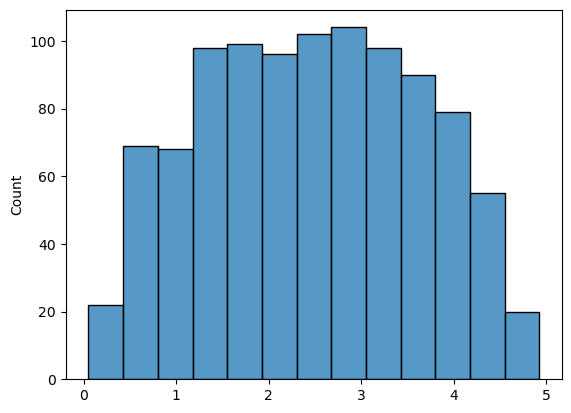

In [21]:
sns.histplot(sample_mv_prior(1000))

In [30]:
outcomes = np.array([
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0],
    [1.0, 2.0, 1.0, 2.0, 1.0, 2.0]
])

b_var = 1
b_loss = 1

In [31]:
@njit
def get_mv_utility(b_var, b_loss, outcomes):
    num_outcomes = outcomes.shape[1] // 2
    utilities = np.empty((outcomes.shape[0], 2))
    for i in range(outcomes.shape[0]):
        utility_a = (
            np.mean(outcomes[i, :num_outcomes])
            + b_var * np.sqrt(np.var(outcomes[i, :num_outcomes]))
            + b_loss * np.min(outcomes[i, :num_outcomes])
        )
        utility_b = (
            np.mean(outcomes[i, num_outcomes:])
            + b_var * np.sqrt(np.var(outcomes[i, num_outcomes:]))
            + b_loss * np.min(outcomes[i, num_outcomes:])
        )
        utilities[i, 0] = utility_a
        utilities[i, 1] = utility_b
    return utilities

In [36]:
%%time
get_mv_utility(b_var, b_loss, outcomes)

CPU times: user 23 μs, sys: 1 μs, total: 24 μs
Wall time: 26.9 μs


array([[2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119],
       [2.80473785, 3.13807119]])

In [167]:
@njit
def get_inv_pt_utility(alpha, lambda_, utilities):
    for i in range(utilities.shape[0]):
        for j in range(utilities.shape[1]):
            if utilities[i, j] >= 0:
                utilities[i, j] = utilities[i, j] ** (1 / alpha)
            else:
                utilities[i, j] = -(np.abs(utilities[i, j]) / lambda_) ** (1 / alpha)
    return utilities

In [168]:
@njit
def get_pt_utility(alpha, lamda, gamble):
    num_outcomes = gamble.shape[1] // 2
    utilities = np.empty((gamble.shape[0], 2))
    for i in range(gamble.shape[0]):
        utility_a = 0.0
        utility_b = 0.0
        for j in range(num_outcomes):
            x_a = gamble[i, j]
            x_b = gamble[i, j + num_outcomes]
            if x_a >= 0:
                utility_a += x_a ** alpha
            else:
                utility_a += -lamda * ((-x_a) ** alpha)
            if x_b >= 0:
                utility_b += x_b ** alpha
            else:
                utility_b += -lamda * ((-x_b) ** alpha)
        utilities[i, 0] = utility_a / num_outcomes
        utilities[i, 1] = utility_b / num_outcomes
    return get_inv_pt_utility(alpha, lamda, utilities)

In [199]:
lamda = 0.8
alpha = 1

outcomes = np.array([
    [720, 570, -230, -980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80],
    [720, 570, -230, 980, 160, -80]
])

In [200]:
%%time
utilities = get_pt_utility(lamda, alpha, outcomes)
utilities

CPU times: user 133 ms, sys: 4.25 ms, total: 137 ms
Wall time: 140 ms


array([[ 284.71698043, -217.62824879],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234],
       [ 284.71698043,  279.57199234]])

In [100]:
@njit
def get_choices()

353.3333333333333